# IOTN-AC dari 3 Annotator — ResNet18, Perbandingan Target Konsensus

Data OMNI kini punya **skor AC dari 3 annotator** per foto. Notebook ini:

1. Mengukur **kesepakatan antar-annotator** (QWK berpasangan, Krippendorff-α, bias
   per-annotator) — ini **batas atas (ceiling)** realistis untuk model.
2. Membentuk beberapa **target konsensus**: mean, median, majority, dan soft-label,
   lalu **melatih ResNet18** (transfer, seperti notebook 1 yang hasilnya terbaik) untuk
   masing-masing dan membandingkannya.
3. Menyebut **metode lain** untuk belajar dari banyak annotator.

> Model dievaluasi terhadap konsensus uji **dan** dibandingkan dengan ceiling manusia —
> agar jelas apakah selisih model tersisa karena model atau karena label yang memang
> tak sepakat.

## 1. Setup & konfigurasi label

In [22]:
import os, time, collections
import numpy as np, openpyxl
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

try:    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError: _HERE = os.getcwd()
PROJECT_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == 'notebooks' else _HERE
DATA_RAW   = os.path.join(PROJECT_ROOT, 'data', 'raw')
# --- pilih sumber gambar ---
INPUT_MODE = 'full'          # 'full' | 'teeth_masked' | 'teeth_masked_crop'
IMG_DIR = os.path.join(PROJECT_ROOT, 'data',
    {'full': 'raw', 'teeth_masked': 'masked', 'teeth_masked_crop': 'masked_crop'}[INPUT_MODE])
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models'); os.makedirs(MODELS_DIR, exist_ok=True)

# --- ATUR SESUAI FILE-MU (1 file, 3 kolom annotator) ---
LABEL_FILE = os.path.join(PROJECT_ROOT, 'data', 'labels', 'Grade AC by Team.xlsx')
KOL_FILE   = 'Nama File'                 # kolom nama berkas foto
KOL_ANNOT  = ['Nana', 'Anin', 'Nico']     # kolom skor tiap annotator
FOLDER     = {'train': 'train', 'val': 'val', 'test': 'test'}   # split ikut folder
GRADE = np.arange(1, 11)

PERANGKAT = ('cuda' if torch.cuda.is_available()
             else ('mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()
                   else 'cpu'))
print('Perangkat:', PERANGKAT, '| INPUT_MODE:', INPUT_MODE, '->', os.path.relpath(IMG_DIR, PROJECT_ROOT))
assert os.path.exists(LABEL_FILE), (
    f'File label 3-annotator tidak ditemukan:\n{LABEL_FILE}\n'
    'Taruh file (1 file, 3 kolom) di data/labels/ lalu sesuaikan LABEL_FILE/KOL_ANNOT.')

Perangkat: mps | INPUT_MODE: full -> data/raw


> **INPUT_MODE** (di bagian 1) menentukan sumber gambar: `full` (data/raw), `teeth_masked`
(data/masked), atau `teeth_masked_crop` (data/masked_crop). Untuk membandingkan: set
`INPUT_MODE`, jalankan ulang **bagian 2 (muat label)** lalu **bagian 10 (cross-validation)**,
catat **QWK OOF** tiap mode. Nama file identik antar-folder, jadi tak ada perubahan lain.

## 2. Muat label 3 annotator

Membaca `KOL_FILE` + 3 kolom skor, mencocokkan ke foto di `data/raw/{train,val,test}` (split mengikuti folder).

In [23]:
def _num(v):
    try: return float(v)
    except (TypeError, ValueError): return np.nan

def muat_3annot():
    wb = openpyxl.load_workbook(LABEL_FILE, data_only=True)
    # cari indeks kolom dari header (di sheet mana pun)
    data = {s: {'path': [], 'A': []} for s in FOLDER}
    for ws in wb.worksheets:
        head = [str(c.value).strip() if c.value is not None else '' for c in ws[1]]
        if KOL_FILE not in head or not all(k in head for k in KOL_ANNOT):
            continue
        i_f = head.index(KOL_FILE); i_a = [head.index(k) for k in KOL_ANNOT]
        for row in ws.iter_rows(min_row=2, values_only=True):
            nama = row[i_f]
            if not nama: continue
            skor = [_num(row[j]) for j in i_a]
            if any(np.isnan(skor)): continue
            for s, sub in FOLDER.items():
                p = os.path.join(IMG_DIR, sub, str(nama).strip())
                if os.path.exists(p):
                    data[s]['path'].append(p); data[s]['A'].append(skor); break
    for s in data:
        data[s]['A'] = np.array(data[s]['A'], dtype=float)
    return data

DATA = muat_3annot()
for s in FOLDER:
    A = DATA[s]['A']
    print(f'{s:5s}: {len(DATA[s]["path"]):4d} foto | rata skor per annotator '
          f'{np.round(A.mean(0),2) if len(A) else "-"}')
A_ALL = np.vstack([DATA[s]['A'] for s in FOLDER]) if all(len(DATA[s]['A']) for s in FOLDER) else DATA['train']['A']

train:  374 foto | rata skor per annotator [4.59 4.77 4.75]
val  :   75 foto | rata skor per annotator [4.69 5.2  4.76]
test :  106 foto | rata skor per annotator [5.41 5.57 5.41]


### Statistik: jumlah foto per grade tiap annotator

Berapa banyak tiap annotator memberi grade 1–10 (semua data). Berguna melihat ketimpangan
kelas (grade langka) dan gaya tiap annotator.

 grade    Nana    Anin    Nico   total
---------------------------------------
     1      70      73      44     187
     2      77      64      76     217
     3      56      48      72     176
     4      46      44      63     153
     5      64      51      64     179
     6      86      82      84     252
     7      82     106      59     247
     8      31      49      50     130
     9      22      18      25      65
    10      21      20      18      59
 total     555     555     555
  rata    4.76    4.98    4.88


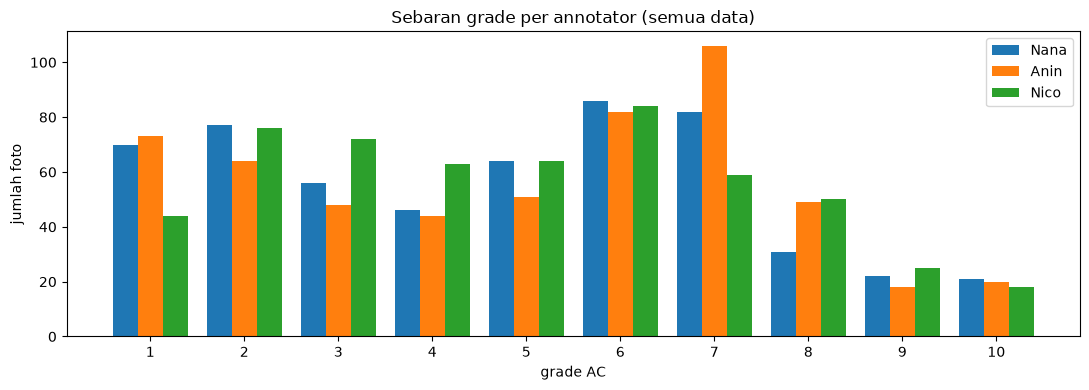

In [24]:
grades = np.arange(1, 11)
tab = np.zeros((10, len(KOL_ANNOT)), int)
for a in range(len(KOL_ANNOT)):
    col = np.clip(np.round(A_ALL[:, a]).astype(int), 1, 10)
    for g in grades: tab[g-1, a] = int((col == g).sum())
print(f'{"grade":>6s} ' + ' '.join(f'{k:>7s}' for k in KOL_ANNOT) + f' {"total":>7s}')
print('-' * (7 + 8 * len(KOL_ANNOT) + 8))
for g in grades:
    print(f'{g:>6d} ' + ' '.join(f'{tab[g-1,a]:>7d}' for a in range(len(KOL_ANNOT))) + f' {tab[g-1].sum():>7d}')
print(f'{"total":>6s} ' + ' '.join(f'{int(tab[:,a].sum()):>7d}' for a in range(len(KOL_ANNOT))))
print(f'{"rata":>6s} ' + ' '.join(f'{A_ALL[:,a].mean():>7.2f}' for a in range(len(KOL_ANNOT))))

fig, ax = plt.subplots(figsize=(11, 4))
w = 0.8 / len(KOL_ANNOT)
for a, k in enumerate(KOL_ANNOT):
    ax.bar(grades + (a - (len(KOL_ANNOT)-1)/2) * w, tab[:, a], w, label=k)
ax.set_xticks(grades); ax.set_xlabel('grade AC'); ax.set_ylabel('jumlah foto')
ax.set_title('Sebaran grade per annotator (semua data)'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Kesepakatan antar-annotator (ceiling)

Bila annotator saja tidak sepakat, model tak mungkin melampaui itu. Metrik: QWK berpasangan (rata-rata), akurasi tepat & ±1 berpasangan, Krippendorff-α (interval), dan bias tiap annotator.

In [25]:
def qwk(a, b, K=10):
    a = np.clip(np.round(a).astype(int), 1, 10) - 1; b = np.clip(np.round(b).astype(int), 1, 10) - 1
    O = np.zeros((K, K))
    for i, j in zip(a, b): O[i, j] += 1
    w = (np.arange(K)[:, None] - np.arange(K)[None, :]) ** 2 / (K - 1) ** 2
    E = np.outer(np.bincount(a, minlength=K), np.bincount(b, minlength=K)) / max(len(a), 1)
    return 1 - (w * O).sum() / max((w * E).sum(), 1e-9)

def krippendorff_interval(A):
    N, m = A.shape
    Do = sum(((A[:, i] - A[:, j]) ** 2).sum() for i in range(m) for j in range(m) if i != j)
    Do /= (N * m * (m - 1))
    v = A.ravel(); n = len(v)
    De = ((v[:, None] - v[None, :]) ** 2).sum() / (n * (n - 1))
    return 1 - Do / De

A = A_ALL; m = A.shape[1]
pares = [(i, j) for i in range(m) for j in range(i + 1, m)]
qwks   = [qwk(A[:, i], A[:, j]) for i, j in pares]
tepat  = [float((np.round(A[:, i]) == np.round(A[:, j])).mean()) for i, j in pares]
pm1    = [float((np.abs(A[:, i] - A[:, j]) <= 1).mean()) for i, j in pares]
print(f'QWK berpasangan     : {np.round(qwks,3)}  (rata {np.mean(qwks):.3f})  <- CEILING')
print(f'Akurasi tepat  pasangan: {np.round(tepat,3)}  (rata {np.mean(tepat):.1%})')
print(f'Akurasi +-1    pasangan: {np.round(pm1,3)}  (rata {np.mean(pm1):.1%})')
print(f'Krippendorff-alpha (interval): {krippendorff_interval(A):.3f}')
print(f'Bias per annotator (rata skor): {np.round(A.mean(0),2)}  | SD antar-annotator per foto: {A.std(1).mean():.2f}')
CEILING_QWK = float(np.mean(qwks))

QWK berpasangan     : [0.932 0.912 0.909]  (rata 0.918)  <- CEILING
Akurasi tepat  pasangan: [0.539 0.447 0.431]  (rata 47.2%)
Akurasi +-1    pasangan: [0.919 0.89  0.868]  (rata 89.2%)
Krippendorff-alpha (interval): 0.918
Bias per annotator (rata skor): [4.76 4.98 4.88]  | SD antar-annotator per foto: 0.45


## 3b. Cohen's Kappa & Krippendorff's α (ordinal)

Dua ukuran kesepakatan yang dikoreksi peluang:

- **Cohen's Kappa** (2 penilai, dihitung berpasangan): `unweighted` (cocok persis),
  `linear`, dan `quadratic` (= QWK; menghukum selisih besar lebih berat).
- **Krippendorff's α (ordinal)**: satu angka untuk ketiga annotator sekaligus, cocok
  untuk skala berjenjang.

Catatan: kappa *unweighted* biasanya jauh lebih rendah daripada *quadratic* karena cocok
persis di skala 1–10 itu jarang — yang penting near-miss ±1, itulah yang ditangkap versi
berbobot.

In [26]:
# Cohen's Kappa (berpasangan, 3 pembobotan) + Krippendorff alpha ordinal
def cohen_kappa(a, b, w='quadratic', K=10):
    a = np.clip(np.round(a).astype(int), 1, 10) - 1; b = np.clip(np.round(b).astype(int), 1, 10) - 1
    O = np.zeros((K, K))
    for i, j in zip(a, b): O[i, j] += 1
    O = O / O.sum(); E = np.outer(O.sum(1), O.sum(0)); idx = np.arange(K)
    if   w is None:      W = 1 - np.eye(K)
    elif w == 'linear':  W = np.abs(idx[:, None] - idx[None, :]) / (K - 1)
    else:                W = (idx[:, None] - idx[None, :]) ** 2 / (K - 1) ** 2   # quadratic = QWK
    return 1 - (W * O).sum() / max((W * E).sum(), 1e-9)

def krippendorff_ordinal(A, K=10):
    A = np.clip(np.round(A).astype(int), 1, K)
    o = np.zeros((K + 1, K + 1))
    for row in A:
        m = len(row)
        for i in range(m):
            for j in range(m):
                if i != j: o[row[i], row[j]] += 1.0 / (m - 1)
    nc = {v: o[v, 1:].sum() for v in range(1, K + 1)}; n = sum(nc.values())
    def d2(c, k):
        lo, hi = min(c, k), max(c, k)
        return (sum(nc[g] for g in range(lo, hi + 1)) - (nc[lo] + nc[hi]) / 2) ** 2
    Do = Dp = 0.0
    for c in range(1, K + 1):
        for k in range(c + 1, K + 1):
            d = d2(c, k); Do += o[c, k] * d; Dp += nc[c] * nc[k] * d
    return 1.0 if Dp == 0 else 1 - (n - 1) * Do / Dp

nama_pasangan = [f'{KOL_ANNOT[i]}-{KOL_ANNOT[j]}' for i, j in pares]
print(f'{"pasangan":16s} {"unweighted":>11s} {"linear":>8s} {"quadratic":>10s}')
print('-' * 48)
for (i, j), t in zip(pares, nama_pasangan):
    print(f'{t:16s} {cohen_kappa(A[:,i],A[:,j],None):>11.3f} '
          f'{cohen_kappa(A[:,i],A[:,j],"linear"):>8.3f} {cohen_kappa(A[:,i],A[:,j],"quadratic"):>10.3f}')
print(f'\nRata Cohen kappa (quadratic) : {np.mean([cohen_kappa(A[:,i],A[:,j],"quadratic") for i,j in pares]):.3f}')
print(f'Krippendorff-alpha (ordinal) : {krippendorff_ordinal(A):.3f}')
print('\nQuadratic-weighted kappa = QWK. Unweighted rendah karena cocok persis jarang;')
print('near-miss +-1 tertangkap oleh versi berbobot.')

pasangan          unweighted   linear  quadratic
------------------------------------------------
Nana-Anin              0.478    0.805      0.932
Nana-Nico              0.377    0.757      0.912
Anin-Nico              0.360    0.747      0.909

Rata Cohen kappa (quadratic) : 0.918
Krippendorff-alpha (ordinal) : 0.912

Quadratic-weighted kappa = QWK. Unweighted rendah karena cocok persis jarang;
near-miss +-1 tertangkap oleh versi berbobot.


## 4. Target konsensus (mean / median / majority / soft)

In [27]:
def majority(row):
    v, c = np.unique(np.round(row).astype(int), return_counts=True)
    return int(v[c.argmax()]) if c.max() >= 2 else float(np.median(row))

def buat_target(A):
    mean = A.mean(1)
    median = np.median(A, 1)
    mayor = np.array([majority(r) for r in A], dtype=float)
    # soft-label: sebaran suara 3 annotator atas grade 1..10 (+ smoothing kecil)
    soft = np.zeros((len(A), 10))
    for i, r in enumerate(A):
        for s in r: soft[i, int(np.clip(round(s), 1, 10)) - 1] += 1
    soft = soft + 0.05
    soft = soft / soft.sum(1, keepdims=True)
    return {'mean': mean, 'median': median, 'majority': mayor, 'soft': soft}

TARGET = {s: buat_target(DATA[s]['A']) for s in FOLDER}
# ringkas beda antar target (pada train)
tt = TARGET['train']
print(f'{"target":10s} {"rata":>7s} {"SD":>7s}')
for k in ['mean', 'median', 'majority']:
    print(f'{k:10s} {tt[k].mean():>7.2f} {tt[k].std():>7.2f}')
print('soft-label: sebaran atas 10 grade (contoh baris 0):', np.round(tt['soft'][0], 2))

target        rata      SD
mean          4.70    2.47
median        4.69    2.53
majority      4.69    2.53
soft-label: sebaran atas 10 grade (contoh baris 0): [0.01 0.59 0.3  0.01 0.01 0.01 0.01 0.01 0.01 0.01]


## 5. Dataset & DataLoader

In [28]:
RATA, SIMPANG = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
tf_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),                          # flip kiri-kanan (AC ~ simetris)
    transforms.RandomAffine(degrees=12, translate=(0.06, 0.06), scale=(0.9, 1.1)),  # rotasi/geser/zoom ringan
    transforms.ColorJitter(0.25, 0.25, 0.25, 0.05),             # variasi pencahayaan/kamera
    transforms.ToTensor(), transforms.Normalize(RATA, SIMPANG),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12))])      # tutup petak acak (anti-overfit)
tf_eval = transforms.Compose([transforms.Resize((224, 224)),
                              transforms.ToTensor(), transforms.Normalize(RATA, SIMPANG)])

class DataAC(Dataset):
    def __init__(self, paths, target, tf): self.paths = paths; self.target = target; self.tf = tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = self.tf(Image.open(self.paths[i]).convert('RGB'))
        y = self.target[i]
        return img, torch.tensor(y, dtype=torch.float32)

def loader(split, target, tf, shuffle):
    return DataLoader(DataAC(DATA[split]['path'], target, tf), batch_size=16, shuffle=shuffle, num_workers=0)

### Berapa banyak augmentasi? (online)

Augmentasi bersifat **online**: setiap epoch, setiap foto latih diberi transformasi acak
**baru** — jadi tidak ada "dataset teraugmentasi" berukuran tetap. Efektifnya model melihat
`n_latih × jumlah_epoch` varian unik (plus MixUp yang mencampur pasangan → kombinasi jauh
lebih banyak). Di bawah ini contoh beberapa augmentasi acak dari satu foto.

Foto latih asli       : 374
Augmentasi            : ONLINE (acak tiap epoch), bukan set tetap
Efektif dilihat model : ~374 varian unik / epoch  ->  374 x jumlah_epoch total
MixUp                 : mencampur pasangan foto -> kombinasi jauh lebih banyak lagi


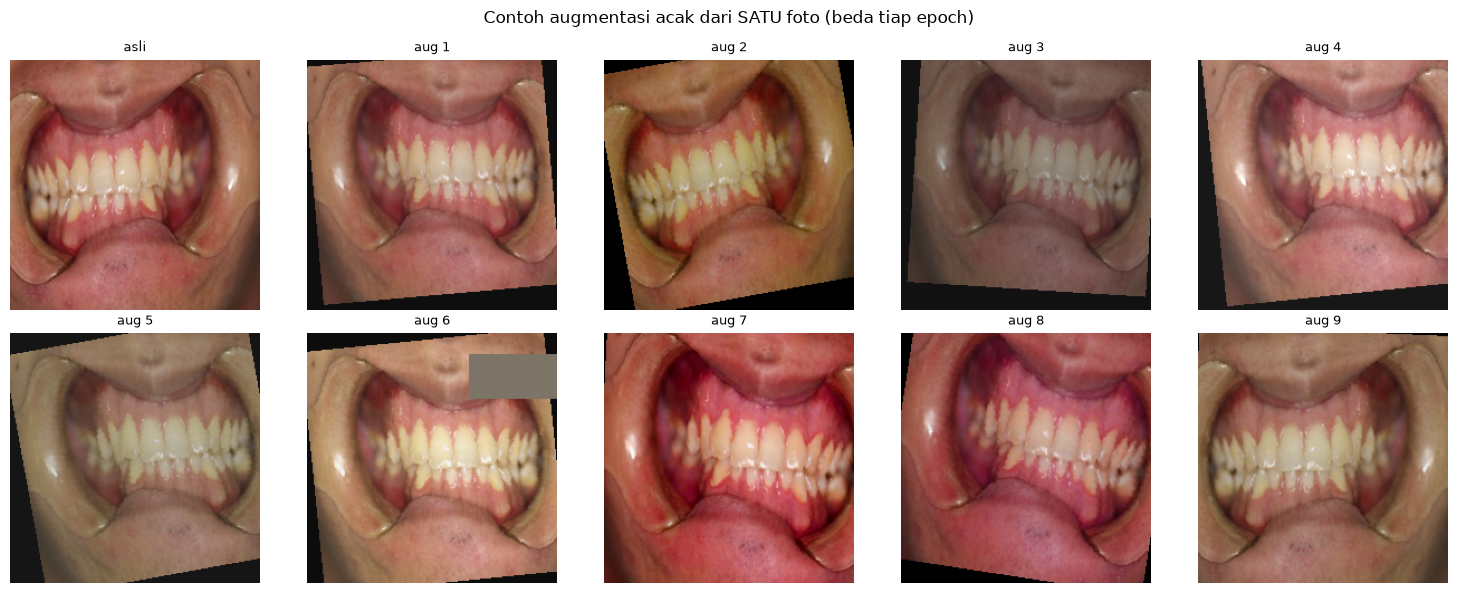

In [29]:
_ntr = len(DATA['train']['path'])
print(f'Foto latih asli       : {_ntr}')
print(f'Augmentasi            : ONLINE (acak tiap epoch), bukan set tetap')
print(f'Efektif dilihat model : ~{_ntr} varian unik / epoch  ->  {_ntr} x jumlah_epoch total')
print(f'MixUp                 : mencampur pasangan foto -> kombinasi jauh lebih banyak lagi')

_r = torch.tensor(RATA).view(3, 1, 1); _s = torch.tensor(SIMPANG).view(3, 1, 1)
_img0 = Image.open(DATA['train']['path'][0]).convert('RGB')
fig, ax = plt.subplots(2, 5, figsize=(15, 6)); ax = ax.ravel()
ax[0].imshow(_img0.resize((224, 224))); ax[0].set_title('asli', fontsize=9); ax[0].axis('off')
for k in range(1, 10):
    t = tf_train(_img0)
    vis = (t * _s + _r).clamp(0, 1).permute(1, 2, 0).numpy()
    ax[k].imshow(vis); ax[k].set_title(f'aug {k}', fontsize=9); ax[k].axis('off')
fig.suptitle('Contoh augmentasi acak dari SATU foto (beda tiap epoch)', fontsize=12)
plt.tight_layout(); plt.show()

## 6. Model ResNet18 (transfer) + fungsi latih

Sama seperti notebook 1: `resnet18` pretrained, lapisan `fc` diganti. Mode regresi (mean/median/majority) atau distribusi (soft).

**Regularisasi anti-overfitting:** dropout 0.4, weight-decay 5e-2, MixUp (α=0.2), plus augmentasi kuat di bagian 5.

In [30]:
def buat_resnet(keluaran=1, dropout=0.4):
    m = models.resnet18(weights='DEFAULT')
    m.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(m.fc.in_features, keluaran))
    return m

def acak(s=42):
    import random; random.seed(s); np.random.seed(s); torch.manual_seed(s)

@torch.no_grad()
def prediksi_reg(model, dl):
    model.eval(); out = []
    for x, _ in dl: out.append(model(x.to(PERANGKAT)).squeeze(1).cpu().numpy())
    return np.concatenate(out)

@torch.no_grad()
def prediksi_soft(model, dl):
    model.eval(); out = []
    for x, _ in dl:
        p = torch.softmax(model(x.to(PERANGKAT)), 1).cpu().numpy()
        out.append(p @ GRADE)                       # nilai harapan grade
    return np.concatenate(out)

def latih(kind, epoch=20, lr=1e-4, wd=5e-2, mixup_alpha=0.2, seed=42):
    acak(seed)
    soft = (kind == 'soft')
    model = buat_resnet(10 if soft else 1).to(PERANGKAT)
    dl_tr = loader('train', TARGET['train'][kind], tf_train, True)
    dl_va = loader('val',   TARGET['val'][kind],   tf_eval,  False)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epoch)
    y_val_ref = np.median(DATA['val']['A'], 1)
    ckpt_dir = os.path.join(MODELS_DIR, 'checkpoints', f'resnet18_{kind}')
    os.makedirs(ckpt_dir, exist_ok=True)
    terbaik, bobot = 1e9, None
    riwayat = {"train_loss": [], "val_mae": []}
    for ep in range(epoch):
        model.train(); total = 0.0; n = 0
        for x, y in dl_tr:
            x = x.to(PERANGKAT); y = y.to(PERANGKAT)
            if mixup_alpha > 0:                                  # MixUp: campur gambar & target
                lam = float(np.random.beta(mixup_alpha, mixup_alpha))
                perm = torch.randperm(x.size(0), device=x.device)
                x = lam * x + (1 - lam) * x[perm]; y = lam * y + (1 - lam) * y[perm]
            if soft:
                loss = torch.nn.functional.kl_div(torch.log_softmax(model(x), 1), y, reduction='batchmean')
            else:
                loss = torch.nn.functional.mse_loss(model(x).squeeze(1), y)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            total += loss.item() * len(x); n += len(x)
        sched.step()
        l_tr = total / max(n, 1)
        pv = prediksi_soft(model, dl_va) if soft else prediksi_reg(model, dl_va)
        mae = float(np.abs(np.clip(np.round(pv), 1, 10) - y_val_ref).mean())
        riwayat['train_loss'].append(l_tr); riwayat['val_mae'].append(mae)
        # --- checkpoint: 'last' tiap epoch, 'best' saat membaik ---
        ckpt = dict(kind=kind, epoch=ep + 1, val_mae=mae,
                    model=model.state_dict(), optim=opt.state_dict())
        torch.save(ckpt, os.path.join(ckpt_dir, 'last.pt'))
        tanda = ''
        if mae < terbaik:
            terbaik = mae; bobot = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(ckpt, os.path.join(ckpt_dir, 'best.pt')); tanda = '  <- terbaik (checkpoint)'
        print(f'  epoch {ep + 1:2d}/{epoch}  train {l_tr:.4f}  val MAE {mae:.3f}{tanda}')
    model.load_state_dict(bobot)
    print(f'  [{kind}] checkpoint: {os.path.relpath(ckpt_dir, PROJECT_ROOT)}/ (best.pt, last.pt)')
    return model, terbaik, riwayat

## 7. Latih & bandingkan semua target

Setiap target melatih satu ResNet18. Evaluasi pada data uji terhadap **median 3 annotator** (referensi netral) plus perbandingan ke ceiling manusia.

In [31]:
def evaluasi(pred, ref):
    p = np.clip(np.round(pred), 1, 10)
    return dict(MAE=float(np.abs(p - ref).mean()),
                pm1=float((np.abs(p - ref) <= 1).mean()),
                QWK=float(qwk(ref, p)))

y_test_ref = np.median(DATA['test']['A'], 1)
hasil = {}
RIWAYAT = {}
for kind in ['mean', 'median', 'majority', 'soft']:
    print(f'\n=== target: {kind} ===')
    model, val_mae, RIWAYAT[kind] = latih(kind)
    dl_te = loader('test', TARGET['test'][kind], tf_eval, False)
    pred = prediksi_soft(model, dl_te) if kind == 'soft' else prediksi_reg(model, dl_te)
    hasil[kind] = evaluasi(pred, y_test_ref)
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, f'ac_resnet18_{kind}.pt'))
    print(f'  val MAE {val_mae:.3f} | test {hasil[kind]}')

print('\n' + '='*54)
print(f'{"target":10s} {"MAE":>7s} {"±1":>8s} {"QWK":>8s}')
print('-'*54)
for k, r in hasil.items():
    print(f'{k:10s} {r["MAE"]:>7.3f} {r["pm1"]:>7.1%} {r["QWK"]:>8.3f}')
print(f'\nCeiling manusia (QWK antar-annotator): {CEILING_QWK:.3f}')
print('Model yang QWK-nya mendekati ceiling berarti sudah sebaik kesepakatan manusia.')


=== target: mean ===
  epoch  1/20  train 21.3901  val MAE 3.400  <- terbaik (checkpoint)
  epoch  2/20  train 11.6224  val MAE 2.987  <- terbaik (checkpoint)
  epoch  3/20  train 5.9565  val MAE 2.107  <- terbaik (checkpoint)
  epoch  4/20  train 3.2767  val MAE 1.413  <- terbaik (checkpoint)
  epoch  5/20  train 2.1168  val MAE 1.227  <- terbaik (checkpoint)
  epoch  6/20  train 1.8047  val MAE 1.320
  epoch  7/20  train 1.8602  val MAE 1.253
  epoch  8/20  train 1.7616  val MAE 1.280
  epoch  9/20  train 1.4005  val MAE 1.173  <- terbaik (checkpoint)
  epoch 10/20  train 1.5165  val MAE 1.413
  epoch 11/20  train 1.3680  val MAE 1.253
  epoch 12/20  train 1.2765  val MAE 1.280
  epoch 13/20  train 1.4344  val MAE 1.280
  epoch 14/20  train 1.1521  val MAE 1.213
  epoch 15/20  train 1.0740  val MAE 1.253
  epoch 16/20  train 1.2638  val MAE 1.253
  epoch 17/20  train 1.4693  val MAE 1.293
  epoch 18/20  train 1.1575  val MAE 1.307
  epoch 19/20  train 1.4061  val MAE 1.280
  epoch 2

## 8. Contoh keluaran: gambar + prediksi AC vs 3 annotator

Memuat model target **mean** (terbaik dari bagian 7), memprediksi beberapa foto uji, dan
menampilkannya berdampingan dengan skor ketiga annotator + rata-ratanya.

model dimuat: models/ac_resnet18_mean.pt


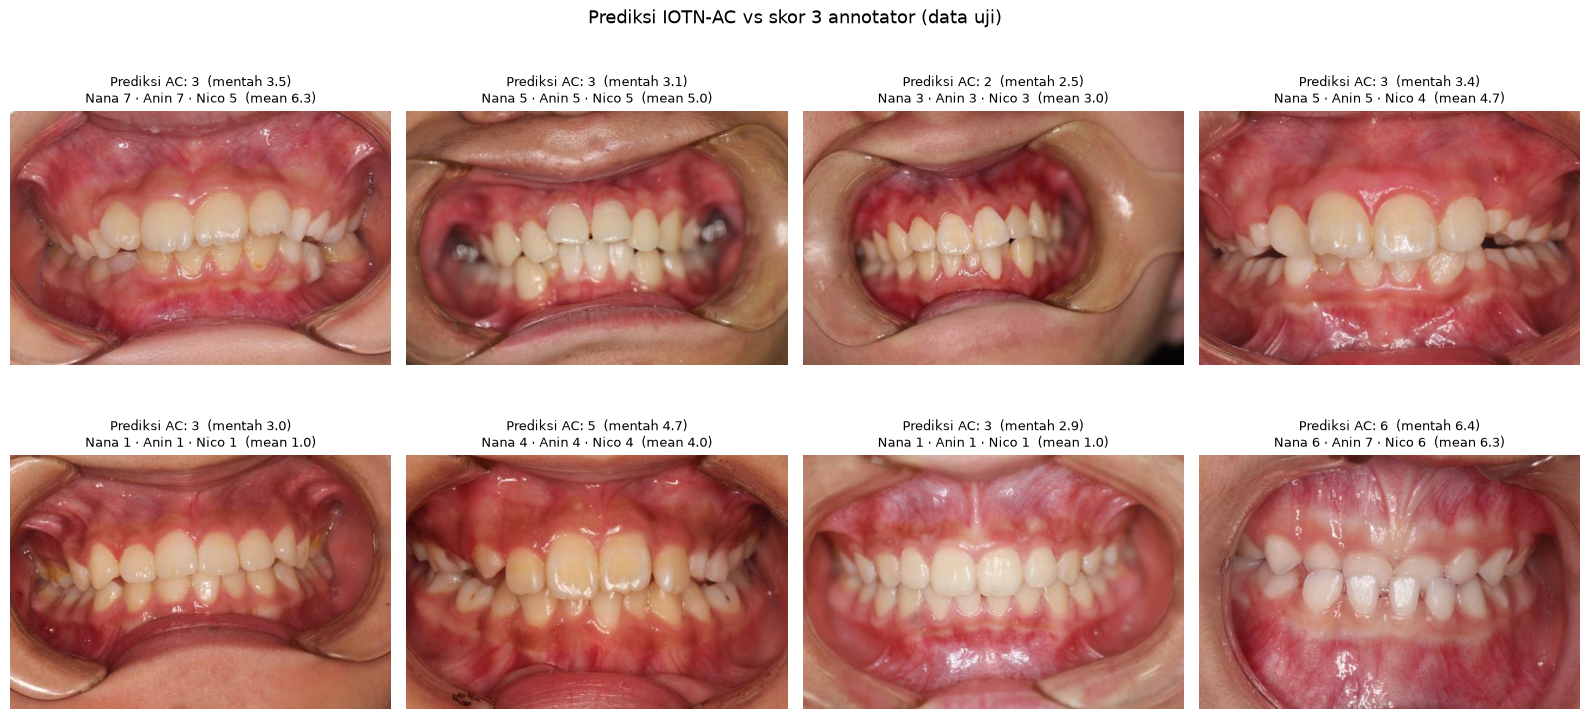

disimpan ke outputs/contoh_prediksi_ac.png


In [32]:
# ============ Contoh keluaran: gambar + prediksi AC ============
MODEL_TAMPIL = 'mean'   # target terbaik (bagian 7)
_m = buat_resnet(1).to(PERANGKAT)
_ck = os.path.join(MODELS_DIR, f'ac_resnet18_{MODEL_TAMPIL}.pt')
if os.path.exists(_ck):
    _m.load_state_dict(torch.load(_ck, map_location=PERANGKAT))
    print('model dimuat:', os.path.relpath(_ck, PROJECT_ROOT))
else:
    print('Berkas', _ck, 'belum ada — jalankan bagian 7 dulu.')
_m.eval()

idx = np.random.default_rng(0).choice(len(DATA['test']['path']),
                                      min(8, len(DATA['test']['path'])), replace=False)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, i in zip(axes.ravel(), idx):
    p = DATA['test']['path'][i]; a = DATA['test']['A'][i]
    img = Image.open(p).convert('RGB')
    with torch.no_grad():
        pred = float(_m(tf_eval(img).unsqueeze(0).to(PERANGKAT)).item())
    grade = int(np.clip(round(pred), 1, 10))
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'Prediksi AC: {grade}  (mentah {pred:.1f})\n'
                 f'{KOL_ANNOT[0]} {a[0]:.0f} · {KOL_ANNOT[1]} {a[1]:.0f} · {KOL_ANNOT[2]} {a[2]:.0f}'
                 f'  (mean {a.mean():.1f})', fontsize=9)
fig.suptitle('Prediksi IOTN-AC vs skor 3 annotator (data uji)', fontsize=13)
plt.tight_layout()
_out = os.path.join(PROJECT_ROOT, 'outputs', 'contoh_prediksi_ac.png')
os.makedirs(os.path.dirname(_out), exist_ok=True)
fig.savefig(_out, dpi=130, bbox_inches='tight'); plt.show()
print('disimpan ke', os.path.relpath(_out, PROJECT_ROOT))

## 8b. Diagnosa — Confusion matrix per grade (1–10)

Model target **mean**. Baris = grade referensi (mean 3 annotator, dibulatkan), kolom =
prediksi model. Diagonal = benar; makin jauh dari diagonal makin besar galatnya. Di bawahnya
dicetak jumlah contoh & recall tiap grade, untuk melihat **grade mana yang paling sering meleset**.

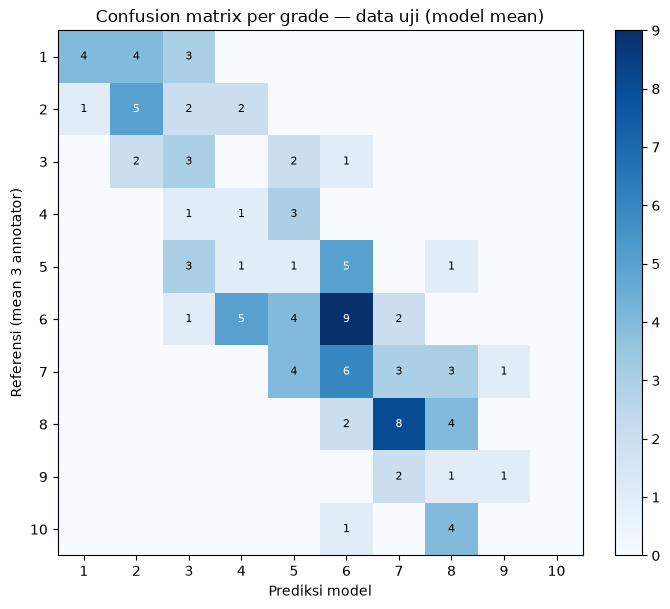

grade    n   recall     MAE
----------------------------
    1   11     36%    0.91
    2   10     50%    0.70
    3    8     38%    1.12
    4    5     20%    0.80
    5   11      9%    1.36
    6   21     43%    0.90
    7   17     18%    1.12
    8   14     29%    0.86
    9    4     25%    1.25
   10    5      0%    2.40

Grade dengan recall rendah / MAE tinggi = paling sering meleset (biasanya ujung skala langka).


In [33]:
# ---- muat model mean + prediksi semua split ----
_m = buat_resnet(1).to(PERANGKAT)
_ckpt = os.path.join(MODELS_DIR, 'ac_resnet18_mean.pt')
assert os.path.exists(_ckpt), 'Jalankan bagian 7 dulu (belum ada models/ac_resnet18_mean.pt).'
_m.load_state_dict(torch.load(_ckpt, map_location=PERANGKAT)); _m.eval()

@torch.no_grad()
def pred_semua(paths, bs=16):
    out = []
    for i in range(0, len(paths), bs):
        xb = torch.stack([tf_eval(Image.open(p).convert('RGB')) for p in paths[i:i+bs]]).to(PERANGKAT)
        out.append(_m(xb).squeeze(1).cpu().numpy())
    return np.concatenate(out)

pred = np.clip(np.round(pred_semua(DATA['test']['path'])), 1, 10).astype(int)
ref  = np.clip(np.round(DATA['test']['A'].mean(1)), 1, 10).astype(int)     # grade referensi = mean 3 annotator

CM = np.zeros((10, 10), int)
for t, p in zip(ref, pred): CM[t-1, p-1] += 1

fig, ax = plt.subplots(figsize=(7.2, 6.2))
im = ax.imshow(CM, cmap='Blues')
ax.set_xticks(range(10)); ax.set_xticklabels(range(1, 11))
ax.set_yticks(range(10)); ax.set_yticklabels(range(1, 11))
ax.set_xlabel('Prediksi model'); ax.set_ylabel('Referensi (mean 3 annotator)')
ax.set_title('Confusion matrix per grade — data uji (model mean)')
for t in range(10):
    for p in range(10):
        if CM[t, p]:
            ax.text(p, t, CM[t, p], ha='center', va='center', fontsize=8,
                    color='white' if CM[t, p] > CM.max()/2 else 'black')
fig.colorbar(im, fraction=0.046)
plt.tight_layout()
_out = os.path.join(PROJECT_ROOT, 'outputs', 'confusion_matrix_ac.png')
os.makedirs(os.path.dirname(_out), exist_ok=True); fig.savefig(_out, dpi=130, bbox_inches='tight'); plt.show()

print(f'{"grade":>5s} {"n":>4s} {"recall":>8s} {"MAE":>7s}')
print('-' * 28)
for g in range(1, 11):
    msk = ref == g; n = int(msk.sum())
    if n == 0: print(f'{g:>5d} {0:>4d} {"-":>8s} {"-":>7s}'); continue
    rec = float((pred[msk] == g).mean()); mae_g = float(np.abs(pred[msk] - g).mean())
    print(f'{g:>5d} {n:>4d} {rec:>7.0%} {mae_g:>7.2f}')
print('\nGrade dengan recall rendah / MAE tinggi = paling sering meleset (biasanya ujung skala langka).')

## 8c. Diagnosa — Train vs Val MAE (overfitting atau underfitting?)

MAE (prediksi dibulatkan vs target mean) pada train/val/test. Bila **train jauh lebih kecil
dari val** → cenderung **overfitting**; bila **keduanya sama-sama tinggi** → cenderung
**underfitting**; selisih kecil → fit seimbang.

In [34]:
def mae_split(s):
    pred = np.clip(np.round(pred_semua(DATA[s]['path'])), 1, 10)
    ref  = DATA[s]['A'].mean(1)                     # target latih = mean 3 annotator
    return float(np.abs(pred - ref).mean())

m_tr, m_va, m_te = mae_split('train'), mae_split('val'), mae_split('test')
gap = m_va - m_tr
print(f'MAE  train {m_tr:.3f} | val {m_va:.3f} | test {m_te:.3f}')
print(f'Selisih val - train : {gap:+.3f}\n')
if gap > 0.15 and m_tr < m_va:
    print('=> Cenderung OVERFITTING: model menghafal data latih (train jauh lebih kecil).')
    print('   Obat: augmentasi lebih kuat, dropout/weight-decay lebih besar, ensemble, lebih banyak data.')
elif m_tr > 0.8 and gap <= 0.15:
    print('=> Cenderung UNDERFITTING: train pun masih tinggi (sinyal/kapasitas kurang).')
    print('   Obat: resolusi input lebih tinggi + ROI, backbone lebih besar, latih lebih lama.')
else:
    print('=> Fit relatif SEIMBANG (selisih train-val kecil).')
    print('   Untuk naik lagi: ensemble + TTA, kalibrasi, bobot grade langka.')

MAE  train 0.610 | val 1.169 | test 1.053
Selisih val - train : +0.559

=> Cenderung OVERFITTING: model menghafal data latih (train jauh lebih kecil).
   Obat: augmentasi lebih kuat, dropout/weight-decay lebih besar, ensemble, lebih banyak data.


## 8d. Grafik diagnostik lengkap (model mean)

Enam panel: kurva belajar (val MAE vs train loss), confusion ternormalisasi (recall per grade),
prediksi vs referensi, sebaran prediksi vs referensi (cek pemampatan ke tengah), bias per grade,
dan sebaran galat. Memerlukan bagian 7 (RIWAYAT) dan 8b (CM, pred_semua) sudah dijalankan.

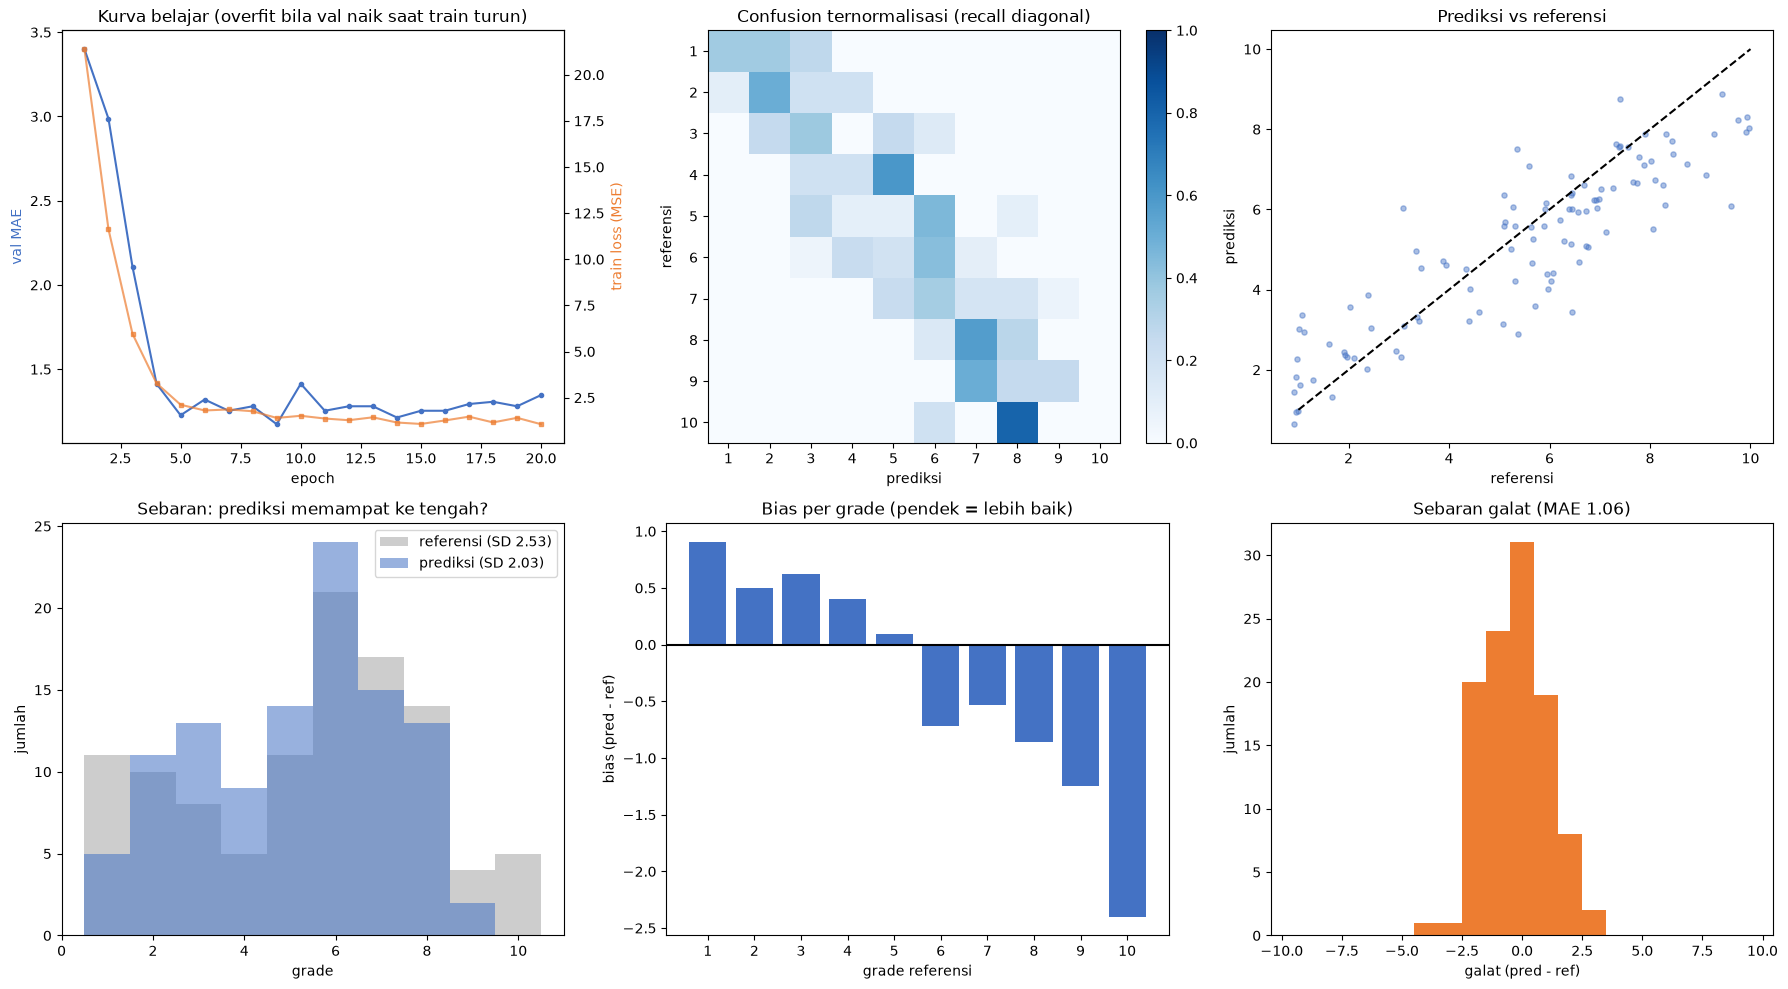

disimpan ke outputs/diagnostik_ac.png


In [35]:
pred_c = pred_semua(DATA['test']['path'])                 # prediksi kontinu (dari 8b)
ref_c  = DATA['test']['A'].mean(1)                        # referensi kontinu (mean 3 annot)
pred_i = np.clip(np.round(pred_c), 1, 10).astype(int); ref_i = np.clip(np.round(ref_c), 1, 10).astype(int)
gs = np.arange(1, 11)

fig, ax = plt.subplots(2, 3, figsize=(18, 10))
riw = RIWAYAT.get('mean') if 'RIWAYAT' in dir() else None
if riw:
    ep = range(1, len(riw['val_mae']) + 1)
    ax[0,0].plot(ep, riw['val_mae'], 'o-', ms=3, color='#4472C4', label='val MAE')
    a2 = ax[0,0].twinx(); a2.plot(ep, riw['train_loss'], 's-', ms=3, color='#ED7D31', alpha=.7, label='train loss')
    ax[0,0].set_xlabel('epoch'); ax[0,0].set_ylabel('val MAE', color='#4472C4'); a2.set_ylabel('train loss (MSE)', color='#ED7D31')
    ax[0,0].set_title('Kurva belajar (overfit bila val naik saat train turun)')
else:
    ax[0,0].axis('off'); ax[0,0].text(.5,.5,'RIWAYAT kosong — jalankan bagian 7', ha='center')

CMn = CM / CM.sum(1, keepdims=True).clip(1)
im = ax[0,1].imshow(CMn, cmap='Blues', vmin=0, vmax=1)
ax[0,1].set_xticks(range(10)); ax[0,1].set_xticklabels(gs); ax[0,1].set_yticks(range(10)); ax[0,1].set_yticklabels(gs)
ax[0,1].set_xlabel('prediksi'); ax[0,1].set_ylabel('referensi'); ax[0,1].set_title('Confusion ternormalisasi (recall diagonal)')
fig.colorbar(im, ax=ax[0,1], fraction=0.046)

ax[0,2].scatter(ref_c + np.random.uniform(-.12,.12,len(ref_c)), pred_c, s=14, alpha=.45, color='#4472C4')
ax[0,2].plot([1,10],[1,10],'k--'); ax[0,2].set_xlabel('referensi'); ax[0,2].set_ylabel('prediksi'); ax[0,2].set_title('Prediksi vs referensi')

bins = np.arange(.5, 11.5)
ax[1,0].hist(ref_c, bins=bins, alpha=.55, label=f'referensi (SD {ref_c.std():.2f})', color='#A5A5A5')
ax[1,0].hist(pred_c, bins=bins, alpha=.55, label=f'prediksi (SD {pred_c.std():.2f})', color='#4472C4')
ax[1,0].set_xlabel('grade'); ax[1,0].set_ylabel('jumlah'); ax[1,0].legend(); ax[1,0].set_title('Sebaran: prediksi memampat ke tengah?')

bias = [ (pred_i[ref_i==g]-g).mean() if (ref_i==g).any() else 0 for g in gs ]
ax[1,1].bar(gs, bias, color='#4472C4'); ax[1,1].axhline(0, c='k'); ax[1,1].set_xticks(gs)
ax[1,1].set_xlabel('grade referensi'); ax[1,1].set_ylabel('bias (pred - ref)'); ax[1,1].set_title('Bias per grade (pendek = lebih baik)')

err = pred_i - ref_i
ax[1,2].hist(err, bins=np.arange(-9.5, 10.5), color='#ED7D31')
ax[1,2].set_xlabel('galat (pred - ref)'); ax[1,2].set_ylabel('jumlah'); ax[1,2].set_title(f'Sebaran galat (MAE {np.abs(err).mean():.2f})')

plt.tight_layout()
_out = os.path.join(PROJECT_ROOT, 'outputs', 'diagnostik_ac.png')
fig.savefig(_out, dpi=120, bbox_inches='tight'); plt.show()
print('disimpan ke', os.path.relpath(_out, PROJECT_ROOT))

## 8e. Ensemble + TTA

- **TTA (Test-Time Augmentation):** tiap foto uji diprediksi pada beberapa versi (asli, flip,
  rotasi ±8°) lalu dirata-ratakan — ensemble mini dari satu model.
- **Ensemble:** latih beberapa ResNet18 dengan seed berbeda pada target **mean**, lalu
  rata-ratakan prediksinya (kontinu, baru dibulatkan).

Dibandingkan: 1 model, 1 model + TTA, dan ensemble + TTA. Menurunkan variansi → biasanya
MAE turun & QWK naik sedikit tapi nyata.

In [36]:
import torchvision.transforms.functional as TF
N_ENSEMBLE = 3          # jumlah model (naikkan ke 5 bila sempat)

@torch.no_grad()
def pred_tta(model, paths, bs=16, pakai_tta=True):
    model.eval(); out = []
    for i in range(0, len(paths), bs):
        xb = torch.stack([tf_eval(Image.open(p).convert('RGB')) for p in paths[i:i+bs]]).to(PERANGKAT)
        if pakai_tta:
            views = [xb, torch.flip(xb, [3]), TF.rotate(xb, 8), TF.rotate(xb, -8)]
            pv = torch.stack([model(v).squeeze(1) for v in views]).mean(0)
        else:
            pv = model(xb).squeeze(1)
        out.append(pv.cpu().numpy())
    return np.concatenate(out)

# latih beberapa model (beda seed) pada target mean
ens = []
for s in range(N_ENSEMBLE):
    print(f'\n--- model ensemble {s+1}/{N_ENSEMBLE} (seed {s}) ---')
    m, _, _ = latih('mean', seed=s)
    torch.save(m.state_dict(), os.path.join(MODELS_DIR, f'ac_resnet18_mean_seed{s}.pt'))
    ens.append(m)

y_ref = np.median(DATA['test']['A'], 1)
p_single     = np.clip(np.round(pred_tta(ens[0], DATA['test']['path'], pakai_tta=False)), 1, 10)
p_single_tta = np.clip(np.round(pred_tta(ens[0], DATA['test']['path'], pakai_tta=True)),  1, 10)
p_ens_raw    = np.mean([pred_tta(m, DATA['test']['path'], pakai_tta=True) for m in ens], axis=0)
p_ens_tta    = np.clip(np.round(p_ens_raw), 1, 10)

print(f'\n{"metode":26s} {"MAE":>7s} {"±1":>8s} {"QWK":>8s}')
print('-' * 52)
for nama, p in [('1 model', p_single), ('1 model + TTA', p_single_tta),
                (f'ensemble x{N_ENSEMBLE} + TTA', p_ens_tta)]:
    r = evaluasi(p, y_ref)
    print(f'{nama:26s} {r["MAE"]:>7.3f} {r["pm1"]:>7.1%} {r["QWK"]:>8.3f}')
print(f'\nCeiling manusia (QWK antar-annotator): {CEILING_QWK:.3f}')


--- model ensemble 1/3 (seed 0) ---
  epoch  1/20  train 20.7924  val MAE 3.147  <- terbaik (checkpoint)
  epoch  2/20  train 11.1372  val MAE 2.920  <- terbaik (checkpoint)
  epoch  3/20  train 6.1088  val MAE 2.240  <- terbaik (checkpoint)
  epoch  4/20  train 3.0305  val MAE 1.907  <- terbaik (checkpoint)
  epoch  5/20  train 1.8866  val MAE 1.507  <- terbaik (checkpoint)
  epoch  6/20  train 1.8042  val MAE 1.387  <- terbaik (checkpoint)
  epoch  7/20  train 1.5214  val MAE 1.307  <- terbaik (checkpoint)
  epoch  8/20  train 1.7241  val MAE 1.347
  epoch  9/20  train 1.4176  val MAE 1.253  <- terbaik (checkpoint)
  epoch 10/20  train 1.4808  val MAE 1.307
  epoch 11/20  train 1.3262  val MAE 1.280
  epoch 12/20  train 1.3749  val MAE 1.147  <- terbaik (checkpoint)
  epoch 13/20  train 1.3109  val MAE 1.347
  epoch 14/20  train 1.3790  val MAE 1.267
  epoch 15/20  train 1.1977  val MAE 1.267
  epoch 16/20  train 1.2741  val MAE 1.173
  epoch 17/20  train 1.2828  val MAE 1.267
  epo

## 9. Metode lain untuk belajar dari banyak annotator

Selain empat target di atas, pendekatan yang bisa diimplementasikan:

- **Label Distribution Learning (LDL)** — target = sebaran penuh atas grade (seperti soft),
  model memprediksi distribusi; menangkap ketidakpastian lebih kaya daripada satu angka.
- **Soft-label + KL/cross-entropy** (sudah dipakai di varian `soft`).
- **Multi-output per-annotator** — model memprediksi ketiga skor sekaligus (3 keluaran),
  lalu diagregasi; head bersama meregularisasi dan memisahkan gaya tiap annotator.
- **Crowd layer / "deep learning from crowds"** (Rodrigues & Pereira, 2018) — model belajar
  prediksi "kebenaran" plus **matriks bias/keandalan tiap annotator** secara bersamaan.
- **Dawid–Skene / EM** — estimasi label laten + keandalan annotator (klasik untuk crowd).
- **Konsensus terbobot keandalan** — annotator yang paling sering menyimpang diberi bobot
  lebih kecil saat membuat target.
- **Pembobotan sampel per kesepakatan** — foto dengan 3 annotator sepakat dilatih lebih
  yakin; foto yang timpang diberi bobot kecil (atau disaring).
- **Trimmed mean / agregasi robust** — buang skor ekstrem sebelum merata-rata.
- **Regresi ordinal (CORN)** pada konsensus — menghormati sifat berjenjang grade
  (lihat notebook 2).
- **Kuantifikasi ketidakpastian** — latih model memprediksi mean **dan** SD antar-annotator,
  sehingga keluarannya menyertakan "seberapa ambigu" foto itu.

Praktik yang disarankan: laporkan selalu metrik model **berdampingan dengan ceiling
antar-annotator** (bagian 3), karena pada tugas estetik yang subjektif, batasnya sering
label itu sendiri — bukan model.

## 10. Cross-Validation (k-fold, lengkap)

Evaluasi yang **stabil** supaya perbandingan tidak lagi tertelan derau test 106 foto:

- **Stratified 5-fold** atas gabungan **train+val** (test tetap holdout independen),
  strata = grade referensi agar sebaran seimbang tiap fold.
- Tiap fold memakai resep penuh: target **mean** + augmentasi kuat + dropout/wd + MixUp,
  evaluasi dengan **TTA**.
- Laporan: per-fold + **mean ± SD** (MAE/±1/QWK), prediksi **out-of-fold (OOF)** gabungan
  sebagai satu angka paling andal, dan **ensemble 5 fold-model** diuji pada test holdout.

Berat (melatih k model). Untuk cek cepat, kecilkan `EPOCH_CV`/`K_FOLD` dulu.

In [37]:
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, Dataset
K_FOLD, EPOCH_CV = 5, 30

# pool train+val (test = holdout independen)
paths_all = DATA['train']['path'] + DATA['val']['path']
A_all = np.vstack([DATA['train']['A'], DATA['val']['A']])
y_all = A_all.mean(1)                                  # target mean
strat = np.clip(np.round(y_all).astype(int), 1, 10)    # stratifikasi per grade

rng = np.random.default_rng(42); fold_of = np.empty(len(paths_all), int)
for g in np.unique(strat):
    ix = np.where(strat == g)[0]; rng.shuffle(ix)
    fold_of[ix] = np.arange(len(ix)) % K_FOLD

class DScv(Dataset):
    def __init__(self, paths, y, tf): self.p = paths; self.y = y; self.tf = tf
    def __len__(self): return len(self.p)
    def __getitem__(self, i):
        return self.tf(Image.open(self.p[i]).convert('RGB')), torch.tensor(self.y[i], dtype=torch.float32)

@torch.no_grad()
def pred_tta_paths(model, paths, bs=16):
    model.eval(); out = []
    for i in range(0, len(paths), bs):
        xb = torch.stack([tf_eval(Image.open(p).convert('RGB')) for p in paths[i:i+bs]]).to(PERANGKAT)
        views = [xb, torch.flip(xb, [3]), TF.rotate(xb, 8), TF.rotate(xb, -8)]
        out.append(torch.stack([model(v).squeeze(1) for v in views]).mean(0).cpu().numpy())
    return np.concatenate(out)

def latih_fold(paths_tr, y_tr, epoch=EPOCH_CV, lr=1e-4, wd=5e-2, mixup_alpha=0.2, seed=42):
    acak(seed); model = buat_resnet(1).to(PERANGKAT)
    dl = DataLoader(DScv(paths_tr, y_tr, tf_train), batch_size=16, shuffle=True, num_workers=0)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epoch)
    for ep in range(epoch):
        model.train()
        for x, y in dl:
            x = x.to(PERANGKAT); y = y.to(PERANGKAT)
            if mixup_alpha > 0:
                lam = float(np.random.beta(mixup_alpha, mixup_alpha)); perm = torch.randperm(x.size(0), device=x.device)
                x = lam * x + (1 - lam) * x[perm]; y = lam * y + (1 - lam) * y[perm]
            loss = torch.nn.functional.mse_loss(model(x).squeeze(1), y)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        sched.step()
    return model

oof = np.zeros(len(paths_all)); rows = []; fold_models = []
for f in range(K_FOLD):
    tr = np.where(fold_of != f)[0]; va = np.where(fold_of == f)[0]
    print(f'--- fold {f+1}/{K_FOLD}: latih {len(tr)} | validasi {len(va)} ---')
    m = latih_fold([paths_all[i] for i in tr], y_all[tr]); fold_models.append(m)
    pv = pred_tta_paths(m, [paths_all[i] for i in va]); oof[va] = pv
    r = evaluasi(np.clip(np.round(pv), 1, 10), np.median(A_all[va], 1)); rows.append(r)
    print(f'   MAE {r["MAE"]:.3f} | ±1 {r["pm1"]:.1%} | QWK {r["QWK"]:.3f}')

MAEs = np.array([r['MAE'] for r in rows]); P1s = np.array([r['pm1'] for r in rows]); QWKs = np.array([r['QWK'] for r in rows])
print(f'\n{"fold":>5s} {"MAE":>7s} {"±1":>8s} {"QWK":>8s}\n' + '-'*32)
for f, r in enumerate(rows, 1): print(f'{f:>5d} {r["MAE"]:>7.3f} {r["pm1"]:>7.1%} {r["QWK"]:>8.3f}')
print('-'*32)
print(f'{"mean":>5s} {MAEs.mean():>7.3f} {P1s.mean():>7.1%} {QWKs.mean():>8.3f}')
print(f'{"SD":>5s} {MAEs.std():>7.3f} {P1s.std():>7.1%} {QWKs.std():>8.3f}')

r_oof = evaluasi(np.clip(np.round(oof), 1, 10), np.median(A_all, 1))
print(f'\nOOF gabungan (n={len(paths_all)}) : MAE {r_oof["MAE"]:.3f} | ±1 {r_oof["pm1"]:.1%} | QWK {r_oof["QWK"]:.3f}  <- estimasi paling andal')
p_test = np.mean([pred_tta_paths(m, DATA['test']['path']) for m in fold_models], axis=0)
r_test = evaluasi(np.clip(np.round(p_test), 1, 10), np.median(DATA['test']['A'], 1))
print(f'Ensemble {K_FOLD} fold-model @ TEST holdout : MAE {r_test["MAE"]:.3f} | ±1 {r_test["pm1"]:.1%} | QWK {r_test["QWK"]:.3f}')
print(f'Ceiling manusia (QWK) : {CEILING_QWK:.3f}')

--- fold 1/5: latih 354 | validasi 95 ---
   MAE 1.053 | ±1 76.8% | QWK 0.793
--- fold 2/5: latih 358 | validasi 91 ---
   MAE 0.901 | ±1 81.3% | QWK 0.872
--- fold 3/5: latih 359 | validasi 90 ---
   MAE 1.056 | ±1 74.4% | QWK 0.805
--- fold 4/5: latih 361 | validasi 88 ---
   MAE 0.852 | ±1 84.1% | QWK 0.877
--- fold 5/5: latih 364 | validasi 85 ---
   MAE 0.941 | ±1 78.8% | QWK 0.842

 fold     MAE       ±1      QWK
--------------------------------
    1   1.053   76.8%    0.793
    2   0.901   81.3%    0.872
    3   1.056   74.4%    0.805
    4   0.852   84.1%    0.877
    5   0.941   78.8%    0.842
--------------------------------
 mean   0.961   79.1%    0.838
   SD   0.081    3.4%    0.034

OOF gabungan (n=449) : MAE 0.962 | ±1 79.1% | QWK 0.838  <- estimasi paling andal
Ensemble 5 fold-model @ TEST holdout : MAE 1.047 | ±1 73.6% | QWK 0.822
Ceiling manusia (QWK) : 0.918


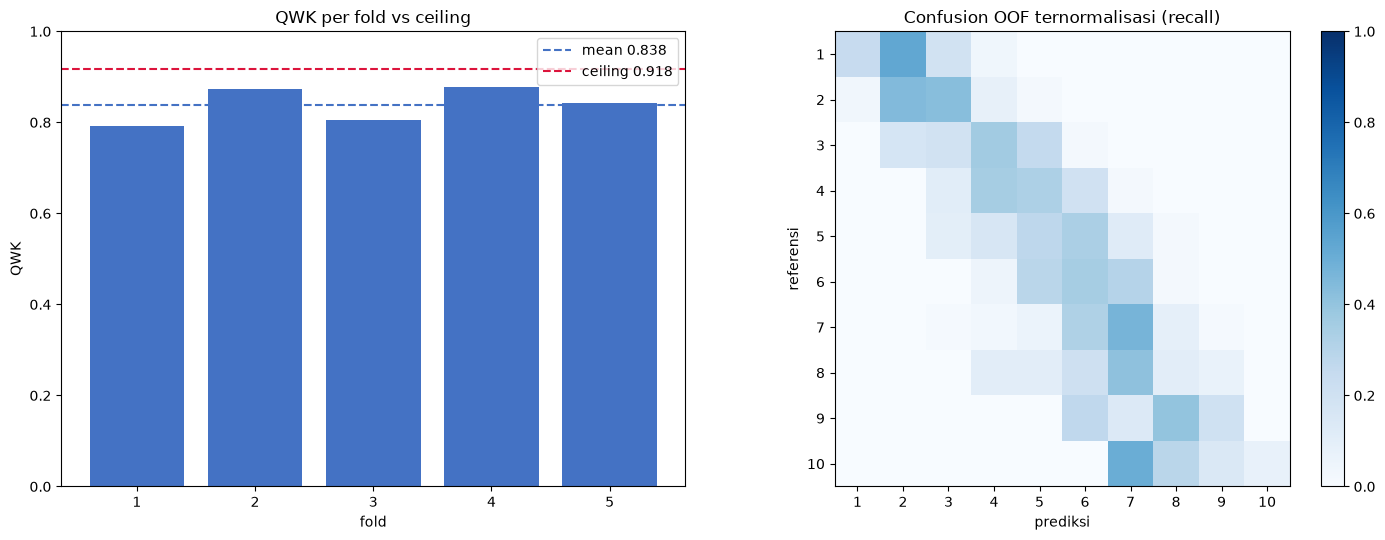

disimpan ke outputs/cv_diagnostik.png


In [38]:
# grafik CV: QWK per fold + confusion OOF ternormalisasi
ref_all = np.clip(np.round(np.median(A_all, 1)).astype(int), 1, 10)
pred_all = np.clip(np.round(oof), 1, 10).astype(int)
CMv = np.zeros((10, 10), int)
for t, p in zip(ref_all, pred_all): CMv[t-1, p-1] += 1

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].bar(range(1, K_FOLD+1), QWKs, color='#4472C4')
ax[0].axhline(QWKs.mean(), ls='--', c='#4472C4', label=f'mean {QWKs.mean():.3f}')
ax[0].axhline(CEILING_QWK, ls='--', c='crimson', label=f'ceiling {CEILING_QWK:.3f}')
ax[0].set_xlabel('fold'); ax[0].set_ylabel('QWK'); ax[0].set_ylim(0, 1); ax[0].legend()
ax[0].set_title('QWK per fold vs ceiling')
im = ax[1].imshow(CMv / CMv.sum(1, keepdims=True).clip(1), cmap='Blues', vmin=0, vmax=1)
ax[1].set_xticks(range(10)); ax[1].set_xticklabels(range(1, 11))
ax[1].set_yticks(range(10)); ax[1].set_yticklabels(range(1, 11))
ax[1].set_xlabel('prediksi'); ax[1].set_ylabel('referensi'); ax[1].set_title('Confusion OOF ternormalisasi (recall)')
fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout()
_out = os.path.join(PROJECT_ROOT, 'outputs', 'cv_diagnostik.png')
fig.savefig(_out, dpi=120, bbox_inches='tight'); plt.show()
print('disimpan ke', os.path.relpath(_out, PROJECT_ROOT))

## 11. Model AC final + ekspor Core ML (deployment)

Model untuk di-deploy: **latih ulang di SELURUH data berlabel** (train+val+test) dengan resep
terpilih, lalu ekspor ke Core ML dengan **normalisasi tertanam** (app cukup kirim piksel).

Prasyarat: `INPUT_MODE = 'teeth_masked_crop'` di bagian 1, dan bagian 2 (muat label) sudah
dijalankan. Performa dilaporkan dari **CV/OOF** (bagian 10); model final ini memakai semua
data agar sekuat mungkin, jadi tak perlu holdout lagi. Butuh `coremltools`.

In [ ]:
# --- 1) latih model AC final di SELURUH data berlabel ---
import copy
assert INPUT_MODE == 'full', "Set INPUT_MODE='teeth_masked_crop' di bagian 1 lalu jalankan ulang bagian 2."
paths_final = DATA['train']['path'] + DATA['val']['path'] + DATA['test']['path']
A_final = np.vstack([DATA[s]['A'] for s in ['train', 'val', 'test']])
y_final = A_final.mean(1)                                  # target mean
dl_final = DataLoader(DataAC(paths_final, y_final, tf_train), batch_size=16, shuffle=True, num_workers=0)

acak(42)
final = buat_resnet(1).to(PERANGKAT)
opt = torch.optim.AdamW(final.parameters(), lr=1e-4, weight_decay=5e-2)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30)
print(f'Melatih model final pada {len(paths_final)} foto (teeth_masked_crop)...')
for ep in range(30):
    final.train(); tot = 0.0
    for x, y in dl_final:
        x = x.to(PERANGKAT); y = y.to(PERANGKAT)
        lam = float(np.random.beta(0.2, 0.2)); perm = torch.randperm(x.size(0), device=x.device)
        x = lam * x + (1 - lam) * x[perm]; y = lam * y + (1 - lam) * y[perm]      # MixUp
        loss = torch.nn.functional.mse_loss(final(x).squeeze(1), y)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); tot += loss.item()*len(x)
    sched.step()
    if ep % 5 == 0 or ep == 29: print(f'  epoch {ep+1:2d}/30  train_loss {tot/len(paths_final):.4f}')
final.eval()
torch.save(final.state_dict(), os.path.join(MODELS_DIR, 'ac_resnet18_final.pt'))
print('bobot final -> models/ac_resnet18_final.pt')

AssertionError: Set INPUT_MODE='teeth_masked_crop' di bagian 1 lalu jalankan ulang bagian 2.

In [ ]:
# --- 2) bungkus (normalisasi tertanam) + ekspor Core ML ---
try:    import coremltools as ct
except ImportError:
    import sys, subprocess; subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'coremltools']); import coremltools as ct

class ACGraderCoreML(nn.Module):
    """Masukan: gambar RGB 1x3x224x224 dalam [0,1]. Normalisasi ImageNet ditanam di sini
    agar app cukup mengirim piksel. Keluaran: skor AC mentah (dibulatkan/di-clip di app)."""
    def __init__(self, model):
        super().__init__(); self.model = copy.deepcopy(model).cpu().eval()
        self.register_buffer('mean', torch.tensor(RATA).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor(SIMPANG).view(1, 3, 1, 1))
    def forward(self, x):
        return self.model((x - self.mean) / self.std)

wrap = ACGraderCoreML(final).eval()
contoh = torch.rand(1, 3, 224, 224)
with torch.no_grad(): terlacak = torch.jit.trace(wrap, contoh)

mlmodel = ct.convert(
    terlacak,
    inputs=[ct.ImageType(name='image', shape=(1, 3, 224, 224),
                         scale=1/255.0, color_layout=ct.colorlayout.RGB)],   # piksel 0-255 -> [0,1]
    outputs=[ct.TensorType(name='ac_score')],
    minimum_deployment_target=ct.target.iOS16)
mlmodel.short_description = 'IOTN-AC skor (1-10, mentah) dari foto gigi frontal teeth_masked_crop'
jalur = os.path.join(MODELS_DIR, 'ACGrader.mlpackage')
mlmodel.save(jalur)
print('Core ML tersimpan ->', os.path.relpath(jalur, PROJECT_ROOT))

# --- 3) sanity: bandingkan PyTorch vs Core ML pada satu foto ---
_p = paths_final[0]
_img = Image.open(_p).convert('RGB').resize((224, 224))
_x = torch.from_numpy(np.asarray(_img).transpose(2, 0, 1) / 255.0).float().unsqueeze(0)
with torch.no_grad(): _pt = float(wrap(_x).squeeze())
try:
    _cm = float(list(mlmodel.predict({'image': _img}).values())[0])
    print(f'PyTorch {_pt:.3f} | Core ML {_cm:.3f} | selisih {abs(_pt-_cm):.4f} (harus ~0)')
except Exception as e:
    print('Prediksi Core ML hanya jalan di macOS:', type(e).__name__)

scikit-learn version 1.8.0 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
XGBoost version 2.0.3 has not been tested with coremltools. You may run into unexpected errors. XGBoost 1.4.2 is the most recent version that has been tested.
Torch version 2.8.0 has not been tested with coremltools. You may run into unexpected errors. Torch 2.7.0 is the most recent version that has been tested.
Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 1323.61 passes/s]


Core ML tersimpan -> models/ACGrader.mlpackage
PyTorch 2.960 | Core ML 2.963 | selisih 0.0031 (harus ~0)


/var/folders/sq/56vv01bj7vl5zkqlsq53t9ym0000gn/T/ipykernel_7345/1643836590.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  _cm = float(list(mlmodel.predict({'image': _img}).values())[0])


### Pakai di app
- Salin `models/ACGrader.mlpackage` ke `IOTN-AC App/MLModels/`.
- Di Swift (`ACGrader.swift`): input `image` 224×224 (Core ML meng-scale piksel & model
  menormalisasi sendiri) → keluaran `ac_score` → `grade = clip(round(ac_score), 1, 10)`.
- Ganti `StubACGrader` dengan `CoreMLACGrader` yang memuat model ini.

## 12. (Jalur A) Ekspor ACGrader 2-keluaran + OOD + kalibrasi → Core ML

Model untuk app iOS gaya **TeethAC** (foto penuh, tanpa segmentasi): ResNet18 dua keluaran
`(grade, vektor fitur)` + `ACGrader_config.json` (centroid OOD, ambang, sigma, kalibrasi).
Normalisasi ImageNet ditanam; input Core ML bertipe **Image** bernama `citra`.

**Set `INPUT_MODE = 'full'` di bagian 1 dan jalankan ulang bagian 2** sebelum sel ini.
Butuh `coremltools`.

In [40]:
# --- latih model full + siapkan OOD/kalibrasi ---
import copy
assert INPUT_MODE == 'full', "Set INPUT_MODE='full' di bagian 1 lalu jalankan ulang bagian 2."
tf_eval_ = tf_eval

model_full, _, _ = latih('mean', epoch=30)      # dilatih di DATA['train'] (full), resep terpilih
model_full = model_full.cpu().eval()

# pisah resnet18: tulang (512 fitur) + kepala (skor)
def pisah_resnet(m):
    mm = copy.deepcopy(m).cpu().eval(); kepala = mm.fc; mm.fc = nn.Identity(); return mm, kepala
tulang, kepala = pisah_resnet(model_full)

@torch.no_grad()
def embed(paths, bs=32):
    out = []
    for i in range(0, len(paths), bs):
        xb = torch.stack([tf_eval_(Image.open(p).convert('RGB')) for p in paths[i:i+bs]])
        f = tulang(xb).numpy(); out.append(f / (np.linalg.norm(f, axis=1, keepdims=True) + 1e-9))
    return np.concatenate(out)

def kmeans(V, k=48, it=60, seed=42):
    rng = np.random.default_rng(seed); C = V[rng.choice(len(V), k, replace=False)].copy()
    for _ in range(it):
        milik = np.argmax(V @ C.T, 1)
        for j in range(k):
            a = V[milik == j]
            if len(a): C[j] = a.mean(0) / (np.linalg.norm(a.mean(0)) + 1e-9)
    return C

E_train = embed(DATA['train']['path']); CENT = kmeans(E_train)
def ood_score(paths): return 1 - (embed(paths) @ CENT.T).max(1)

ood_val = ood_score(DATA['val']['path'])
OOD_THRESHOLD = float(np.quantile(ood_val, 0.99) * 1.1)     # longgar: ~1% foto valid tertolak

@torch.no_grad()
def skor_val():
    out = []
    for i in range(0, len(DATA['val']['path']), 32):
        xb = torch.stack([tf_eval_(Image.open(p).convert('RGB')) for p in DATA['val']['path'][i:i+32]])
        out.append((kepala(tulang(xb)).squeeze(1)).numpy())
    return np.concatenate(out)
pv = skor_val(); yv = np.median(DATA['val']['A'], 1)
# kalibrasi linear (samakan mean & SD prediksi ke label)
m0, s0 = float(pv.mean()), float(pv.std() + 1e-9); m1, s1 = float(yv.mean()), float(yv.std())
KAL = dict(tipe='linear', m0=round(m0, 6), s0=round(s0, 6), m1=round(m1, 6), s1=round(s1, 6))
pv_kal = m1 + (pv - m0) * (s1 / s0)
SIGMA_SISA = float((pv_kal - yv).std())
print(f'OOD threshold {OOD_THRESHOLD:.3f} | sigma_sisa {SIGMA_SISA:.3f} | centroid {CENT.shape}')

  epoch  1/30  train 21.3901  val MAE 3.400  <- terbaik (checkpoint)
  epoch  2/30  train 11.6131  val MAE 3.013  <- terbaik (checkpoint)
  epoch  3/30  train 5.9152  val MAE 2.107  <- terbaik (checkpoint)
  epoch  4/30  train 3.2361  val MAE 1.427  <- terbaik (checkpoint)
  epoch  5/30  train 2.0873  val MAE 1.200  <- terbaik (checkpoint)
  epoch  6/30  train 1.7926  val MAE 1.320
  epoch  7/30  train 1.8809  val MAE 1.253
  epoch  8/30  train 1.7494  val MAE 1.267
  epoch  9/30  train 1.4183  val MAE 1.227
  epoch 10/30  train 1.5301  val MAE 1.440
  epoch 11/30  train 1.3532  val MAE 1.173  <- terbaik (checkpoint)
  epoch 12/30  train 1.3002  val MAE 1.267
  epoch 13/30  train 1.4586  val MAE 1.280
  epoch 14/30  train 1.1349  val MAE 1.227
  epoch 15/30  train 1.0952  val MAE 1.240
  epoch 16/30  train 1.2590  val MAE 1.227
  epoch 17/30  train 1.4798  val MAE 1.200
  epoch 18/30  train 1.1617  val MAE 1.240
  epoch 19/30  train 1.3565  val MAE 1.213
  epoch 20/30  train 0.9373  va

In [43]:
# --- model 2-keluaran + ekspor Core ML + config.json ---
try:    import coremltools as ct
except ImportError:
    import sys, subprocess; subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'coremltools']); import coremltools as ct

class ACGrader(nn.Module):
    """Masukan: RGB 1x3x224x224 dalam [0,1]. Keluaran: (grade mentah, vektor fitur norm-1).
    Normalisasi ImageNet ditanam."""
    def __init__(self, tulang, kepala, rata, simpang):
        super().__init__(); self.tulang = tulang.eval(); self.kepala = kepala.eval()
        self.register_buffer('rata', torch.tensor(rata).view(1, 3, 1, 1))
        self.register_buffer('simpang', torch.tensor(simpang).view(1, 3, 1, 1))
    def forward(self, x):
        x = (x - self.rata) / self.simpang
        f = self.tulang(x); g = self.kepala(f)
        return g, f / (f.norm(dim=1, keepdim=True) + 1e-9)

paket = ACGrader(copy.deepcopy(tulang), copy.deepcopy(kepala), RATA, SIMPANG).eval()
ex = torch.rand(1, 3, 224, 224)
with torch.no_grad(): ts = torch.jit.trace(paket, ex)
mlmodel = ct.convert(ts,
    inputs=[ct.ImageType(name='citra', shape=(1, 3, 224, 224), scale=1/255.0, color_layout=ct.colorlayout.RGB)],
    outputs=[ct.TensorType(name='grade'), ct.TensorType(name='vektor')],
    minimum_deployment_target=ct.target.iOS15)
mlmodel.short_description = 'IOTN-AC (foto penuh) — skor + vektor fitur untuk validasi OOD'
mlmodel.save(os.path.join(MODELS_DIR, 'ACGrader.mlpackage'))

cfg = dict(arsitektur='resnet18', ukuran_masukan=[224, 224], normalisasi_di_dalam_model=True,
           rata=list(map(float, RATA)), simpangan=list(map(float, SIMPANG)),
           grade_min=1, grade_max=10,
           ood_threshold=round(OOD_THRESHOLD, 6), centroid=np.round(CENT, 5).tolist(),
           sigma_sisa=round(SIGMA_SISA, 6), kalibrasi=KAL)
with open(os.path.join(MODELS_DIR, 'ACGrader_config.json'), 'w') as f: json.dump(cfg, f, indent=1)
print('Tersimpan: models/ACGrader.mlpackage + models/ACGrader_config.json')
print('Salin KEDUANYA ke IOTN-AC App/MLModels/ (config.json juga masuk target).')

Tuple detected at graph output. This will be flattened in the converted model.
Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 1092.10 passes/s]


Tersimpan: models/ACGrader.mlpackage + models/ACGrader_config.json
Salin KEDUANYA ke IOTN-AC App/MLModels/ (config.json juga masuk target).


In [42]:
import json